# Fine Res Initial

In [129]:
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

pip 25.3 from C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)



In [130]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [131]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

In [132]:
qd.start_client('192.168.3.1')

In [133]:
from logging import config


default_config = qd.NVConfiguration()



# Important Missing Params:
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500


default_config.relax_delay_tus = 3 # Must be 3 us to let singlet state settle.


default_config.adc_channel = 0
default_config.mw_channel = 0
default_config.mw_fMHz = 500
default_config.mw_gain = 5000 # check user if do two amps for min max
default_config.mw_nqz = 1

# Sweep params
# should check the user to make sure min samples is something and max
# Triggering
default_config.laser_gate_pmod = 0 
default_config.mw_to_laser_delay_tns = 555

default_config.laser_on_tus = 5  # Increased to allow larger readout offsets
default_config.readout_reference_start_tus = 3.5  # near end of laser pulse
default_config.readout_integration_tns = 500
default_config.laser_readout_offset_tus = 1.2 # TO Be Changed

default_config.pulse_seq_delay_tus = 10 # NOTE: NO LONGER USED?
default_config.pre_init = True
default_config.get_reference = True

default_config.reps = 10000

In [134]:
qd.laser_on(copy(default_config))

2

In [135]:
qd.laser_off(copy(default_config))

0

In [136]:
from qickdawg.nvtestsuite.counting_duration_fine_res import CountingDurationFineRes

config = copy(default_config)



config.mw_duration_tdds = 1500

config.reps = 5000

config.mw_gain = 26000
config.mw_fMHz = 1846 # 1859
config.mw_pi_tdds = 590

config.readout_integration_tns = 20


config.reps = 200000

delays = np.arange(800, 1600, 20)

def _as_scalar(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 1:
        return float(arr)
    return float(np.mean(arr))

# Basic practical fix: discard one dummy acquisition before storing data.
config.laser_readout_offset_tns = int(delays[0])
_ = CountingDurationFineRes(config).acquire()

results = None
for i in delays:
    config.laser_readout_offset_tns = int(i)

    prog = CountingDurationFineRes(config)
    d = prog.acquire()

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.array([_as_scalar(d[key])], dtype=float)
        results.delay = np.array([config.laser_readout_offset_tus], dtype=int)
    else:
        for key in d.keys():
            results[key] = np.append(results[key], _as_scalar(d[key]))
        results.delay = np.append(results.delay, config.laser_readout_offset_tus)

print(f"Stored {len(results.delay)} points.")

Stored 40 points.


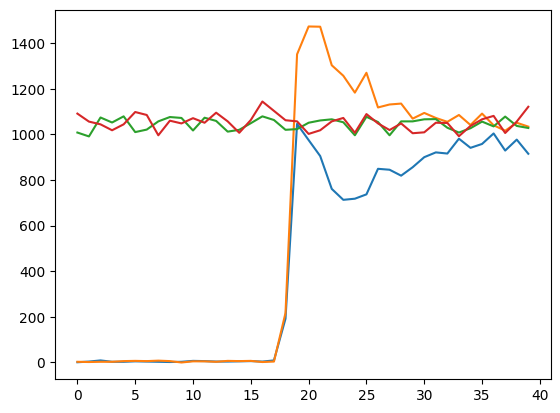

In [137]:
plt.plot(results.signal1)
plt.plot(results.signal2)
plt.plot(results.reference1)
plt.plot(results.reference2)

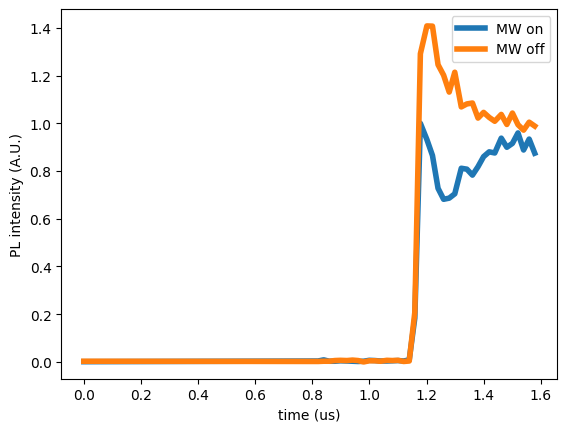

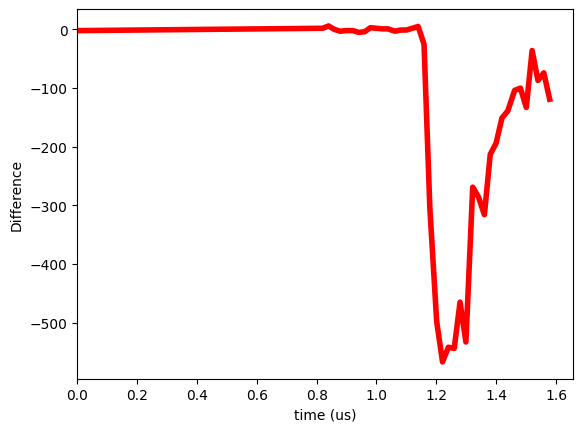

laser_readout_offset is approximately 1.178 us (362 treg)


In [138]:
# Here we plot the readout window data for the microwave pluse on and the microwave off
data_off = results.signal2
data_on = results.signal1

t = np.array(results.delay)
x = data_on
x2 = data_off

plt.plot(t, x/np.max(x), linewidth=4)
plt.plot(t, x2/np.max(x), linewidth=4) 

plt.legend(['MW on', 'MW off'])
plt.xlabel('time (us)')
plt.ylabel('PL intensity (A.U.)')
# plt.xlim(0, 190)
# plt.ylim(0, 1.1)
plt.show()

plt.plot(t, x - x2, c='red', linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, )
plt.show()

config.one_treg = 1
print('laser_readout_offset is approximately {} us '.format(np.round(results.delay[np.where(x/np.max(x) > 0.8)[0][0]], 3)) + 
      '({} treg)'.format(int(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]/config.one_tus)))

In [139]:
from qickdawg.nvtestsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

config.add_unitless_linear_sweep("mw_duration_tdds", 50, 3000, delta=20)
config.mw_gain = 26000
config.mw_fMHz = 1846
config.reps = 300000
# config.readout_integration_tns = 1000

prog = RabiFineRes(config)
d = prog.acquire(progress=True)


Requested 50 to 3000 by 20
Instead using 50 to 3010 by 20 in 148


100%|██████████| 44400000/44400000 [13:07<00:00, 56361.13it/s]


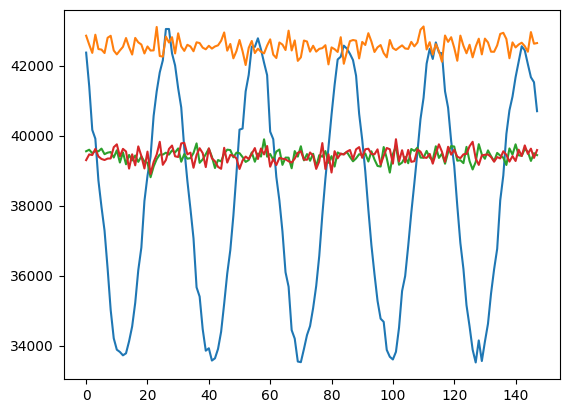

In [140]:
plt.plot(d.signal1)
plt.plot(d.signal2)
plt.plot(d.reference1)
plt.plot(d.reference2)

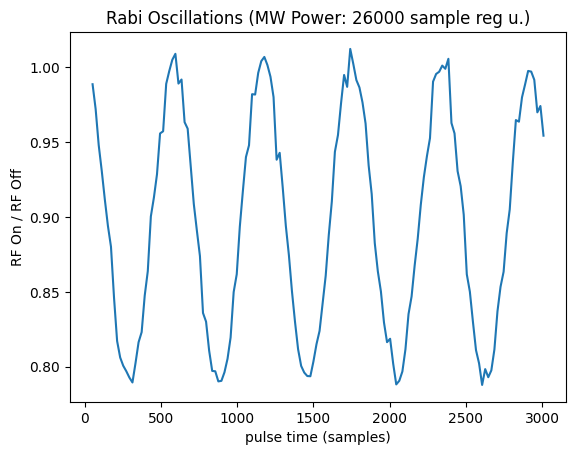

In [141]:
plt.plot(d.sweep_treg, d.signal1/d.signal2)

plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} sample reg u.)')
plt.ylabel('RF On / RF Off')
plt.xlabel('pulse time (samples)')
plt.show()

In [142]:
import numpy as np

print("type(d):", type(d))
print("ndim:", np.ndim(d))
print("shape:", np.shape(d))

arr = np.asarray(d)
axis_20k = [ax for ax, n in enumerate(arr.shape) if n == 200000]
print("axis with length 20000:", axis_20k)

# Sum over the long axis and inspect the 4-wide axis behavior.
if axis_20k:
    summed = arr.sum(axis=axis_20k[0])
    print("shape after summing 20,000 axis:", summed.shape)
    print("summed values:", summed)
else:
    print("No axis of length 20000 found in d.")

if arr.ndim == 2 and arr.shape[1] == 4:
    print("Per-column means (4-wide columns):", arr.mean(axis=0))
    print("Per-column std (4-wide columns):", arr.std(axis=0))
elif arr.ndim == 2 and arr.shape[0] == 4:
    print("Per-row means (4-wide rows):", arr.mean(axis=1))
    print("Per-row std (4-wide rows):", arr.std(axis=1))
else:
    print("Could not directly infer a 4-wide axis orientation from shape.")

type(d): <class 'itemattribute.item_attribute.ItemAttribute'>
ndim: 0
shape: ()
axis with length 20000: []
No axis of length 20000 found in d.
Could not directly infer a 4-wide axis orientation from shape.


Using 3-parameter no-decay fit (tau is not identifiable (effectively no measurable decay)).
[A, T, C] = [1.04836063e-01 5.84281126e+02 8.96043655e-01]


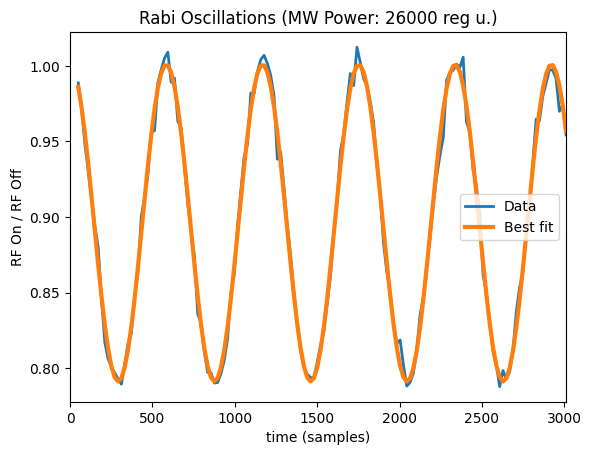

Pi/2 pulse is approximately 146.07 samples


In [143]:
import warnings
from scipy.optimize import OptimizeWarning

def decaying_cos(x, A, T, C, tau):

    return A * (np.cos(x*2*np.pi/T))*np.exp(-x/tau) + C

def no_decay_cos(x, A, T, C):
    return A * np.cos(x * 2 * np.pi / T) + C


t = np.asarray(d.sweep_treg, dtype=float)
x = np.asarray(d.signal1 / d.signal2, dtype=float)

# Try 4-parameter decaying fit first.
p0_full = [0.1, 600.0, float(np.mean(x)), 3000.0]
bounds_full = ([0.0, 100.0, 0.0, 10.0], [1.0, 5000.0, 2.0, 1e7])

use_no_decay = False
fit_reason = ""

try:
    with warnings.catch_warnings():
        warnings.simplefilter("error", OptimizeWarning)
        param4, cov4 = curve_fit(
            decaying_cos,
            t,
            x,
            p0=p0_full,
            bounds=bounds_full,
            maxfev=20000,
        )

    tau = float(param4[3])
    finite_cov = np.all(np.isfinite(cov4))
    tau_effectively_infinite = tau > 10 * (np.max(t) - np.min(t))

    if (not finite_cov) or tau_effectively_infinite:
        use_no_decay = True
        fit_reason = "tau is not identifiable (effectively no measurable decay)"
except (RuntimeError, OptimizeWarning, ValueError) as exc:
    use_no_decay = True
    fit_reason = f"4-parameter fit failed: {exc}"

if use_no_decay:
    p0_3 = [0.1, 600.0, float(np.mean(x))]
    bounds_3 = ([0.0, 100.0, 0.0], [1.0, 5000.0, 2.0])
    param3, cov3 = curve_fit(
        no_decay_cos,
        t,
        x,
        p0=p0_3,
        bounds=bounds_3,
        maxfev=20000,
    )
    yfit = no_decay_cos(t, *param3)
    print(f"Using 3-parameter no-decay fit ({fit_reason}).")
    print("[A, T, C] =", param3)
    period_samples = float(param3[1])
else:
    yfit = decaying_cos(t, *param4)
    print("Using 4-parameter decaying fit.")
    print("[A, T, C, tau] =", param4)
    period_samples = float(param4[1])

plt.plot(t, x, label="Data", linewidth=2)
plt.plot(t, yfit, label="Best fit", linewidth=3)
plt.title(f"Rabi Oscillations (MW Power: {config.mw_gain} reg u.)")
plt.ylabel("RF On / RF Off")
plt.xlabel("time (samples)")
plt.xlim(0, np.max(t))
plt.ylim(np.min(x) - 0.01, np.max(x) + 0.01)
plt.legend()
plt.show()

print(f"Pi/2 pulse is approximately {period_samples / 4:.2f} samples")